# Prediksi Kelulusan Mahasiswa Menggunakan Machine Learning

## Business Understanding

### Latar Belakang

Kelulusan mahasiswa tepat waktu merupakan salah satu indikator penting dalam mengevaluasi kualitas pendidikan di perguruan tinggi. Namun, banyak institusi masih mengalami kesulitan dalam mengidentifikasi mahasiswa yang berpotensi terlambat lulus sejak dini. Akibatnya, tindakan pencegahan atau pendampingan akademik sering terlambat diberikan.

Machine Learning dapat dimanfaatkan untuk mempelajari pola dari data akademik mahasiswa sehingga mampu memprediksi kemungkinan mahasiswa mengalami dropout atau tidak. Hasil prediksi tersebut diharapkan dapat membantu pihak kampus dalam mengambil keputusan secara lebih cepat dan tepat.

### Permasalahan

- Sulit mengidentifikasi mahasiswa yang berpotensi mengalami dropout sejak dini.
- Monitoring akademik masih dilakukan secara manual.
- Belum terdapat sistem prediksi yang mampu membantu pengambilan keputusan berbasis data.

### Tujuan

- Membangun model Machine Learning untuk memprediksi status kelulusan mahasiswa.
- Membandingkan performa Decision Tree dan Logistic Regression.

# Data Understanding

Pada tahap ini dilakukan eksplorasi dataset untuk memahami struktur data, tipe data, jumlah data, distribusi kelas, serta karakteristik setiap fitur sebelum dilakukan proses preprocessing.

In [204]:
import pandas as pd

df = pd.read_csv('/content/student_dropout_dataset_v3.csv')

df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [205]:
# 1. Melihat informasi dataset untuk memastikan tipe data
print("=== INFORMASI DATASET ===")
df.info()

print("\n=== PROPORSISI KOLOM TARGET (DROPOUT) ===")
# 2. Mengecek jumlah kelas pada kolom target yang benar
print(df['Dropout'].value_counts())

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 

##Dataset Overview

In [206]:
df.describe()

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


## Missing Value

Pengecekan missing value dilakukan untuk mengetahui apakah terdapat data yang kosong pada setiap fitur.

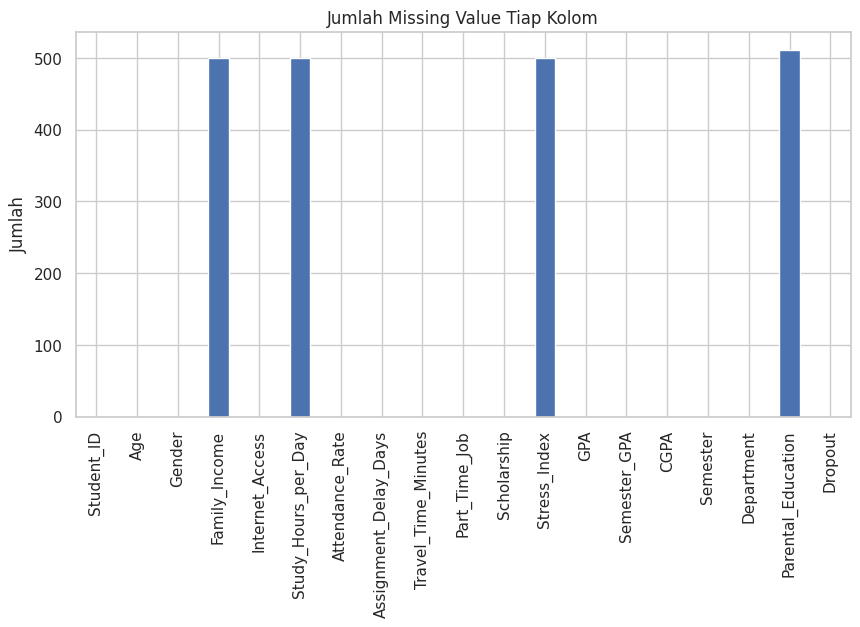

In [207]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title("Jumlah Missing Value Tiap Kolom")
plt.ylabel("Jumlah")
plt.show()

### Duplicate Data Analysis

In [208]:
duplicates = df.duplicated().sum()

print(f"Jumlah data duplikat: {duplicates}")

Jumlah data duplikat: 0


### Data Inconsistency Analysis
Berdasarkan hasil pemeriksaan dataset, tidak ditemukan inkonsistensi pada penamaan kategori maupun tipe data. Setiap atribut telah memiliki tipe data yang sesuai sehingga dapat digunakan pada tahap preprocessing setelah dilakukan penanganan missing values.

### Outlier Analysis

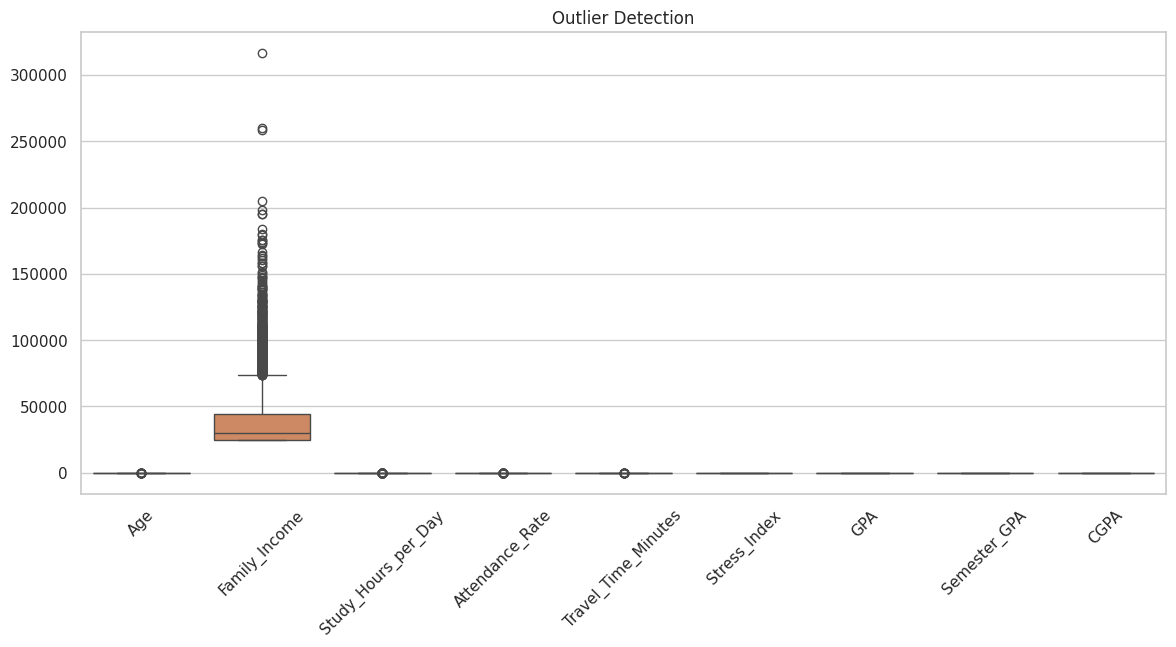

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_columns = [
    'Age',
    'Family_Income',
    'Study_Hours_per_Day',
    'Attendance_Rate',
    'Travel_Time_Minutes',
    'Stress_Index',
    'GPA',
    'Semester_GPA',
    'CGPA'
]

plt.figure(figsize=(14,6))
sns.boxplot(data=df[numerical_columns])

plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

## Target Distribution

Visualisasi ini digunakan untuk melihat keseimbangan jumlah kelas pada variabel target.

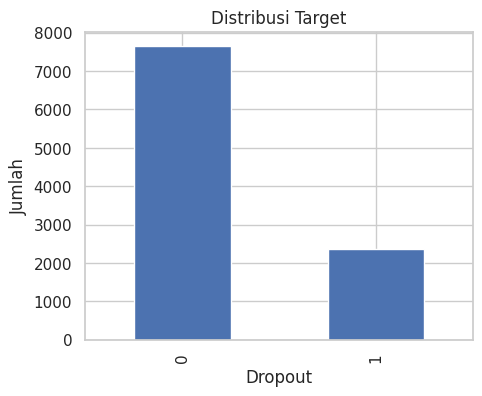

In [210]:
plt.figure(figsize=(5,4))
df['Dropout'].value_counts().plot(kind='bar')
plt.title("Distribusi Target")
plt.xlabel("Dropout")
plt.ylabel("Jumlah")
plt.show()

## Numerical Feature Distribution

Histogram digunakan untuk melihat penyebaran nilai pada setiap fitur numerik.

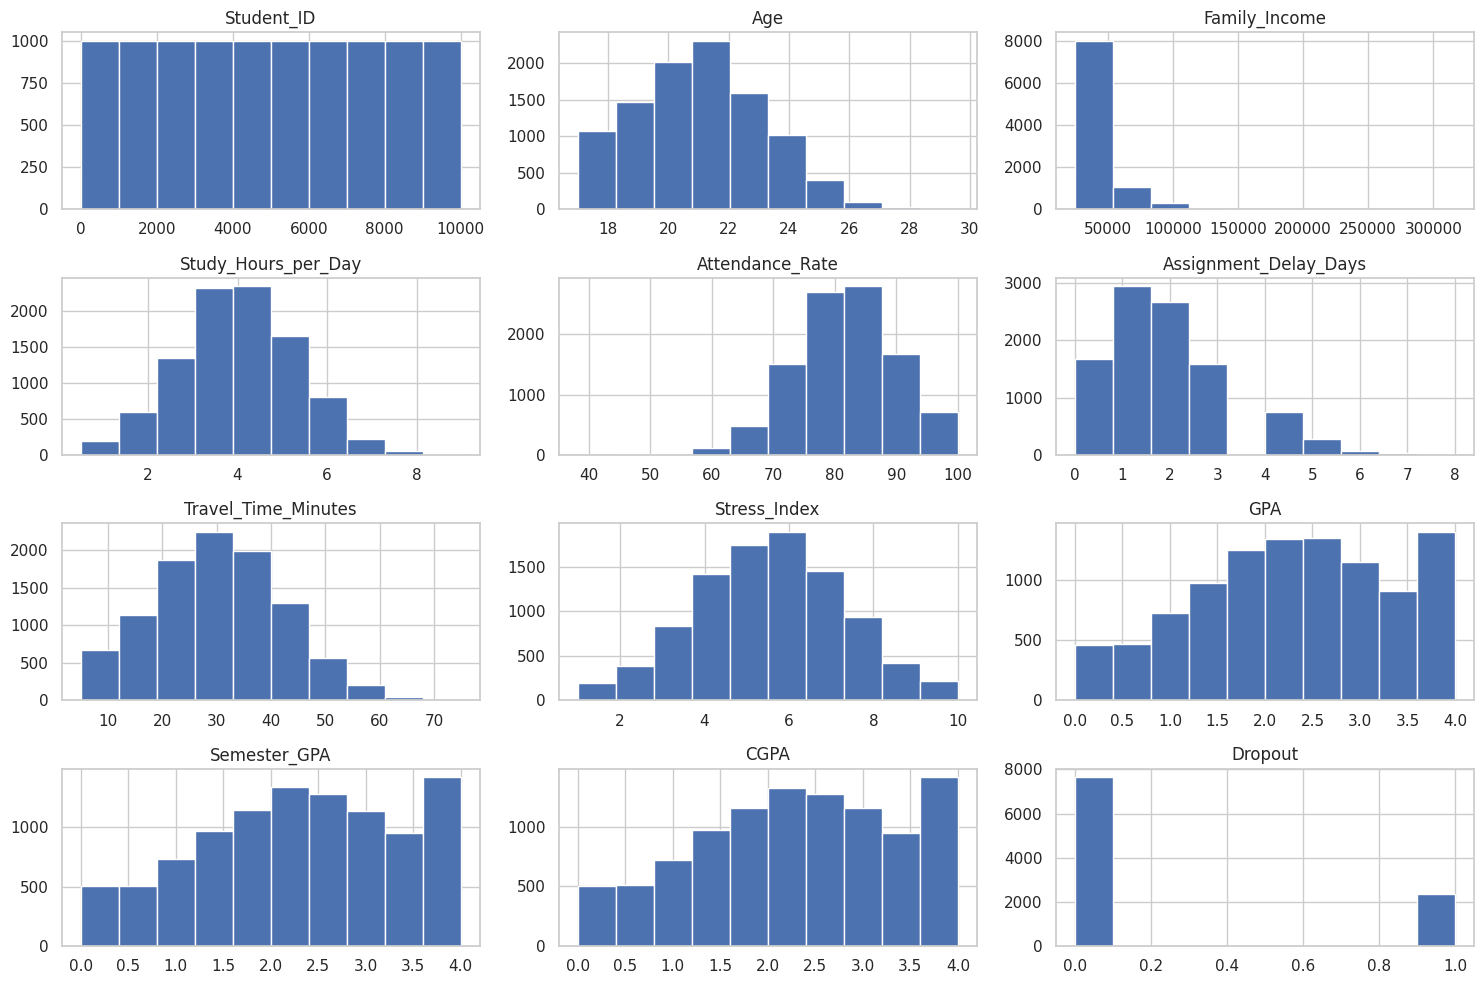

In [211]:
numeric = df.select_dtypes(include=['int64','float64'])

numeric.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

## Correlation Analysis

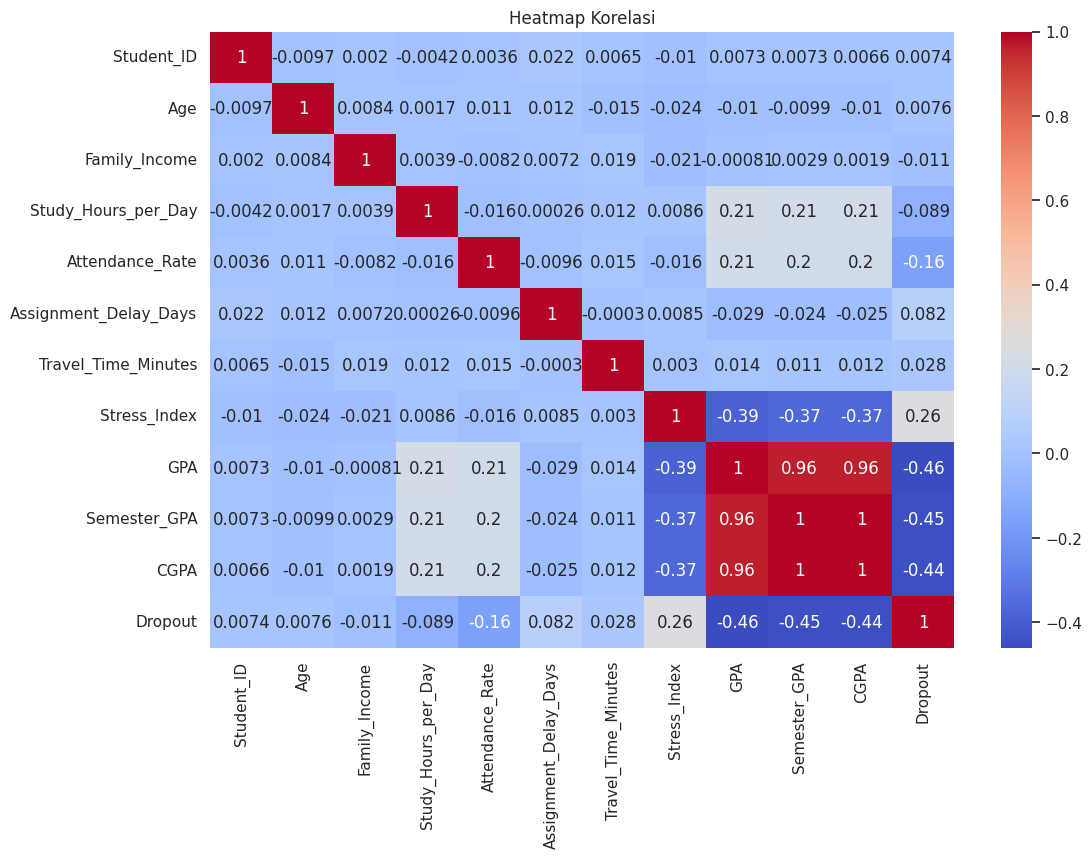

In [212]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Heatmap Korelasi")
plt.savefig("correlation_heatmap.png",dpi=300,bbox_inches="tight")
plt.show()

# Data Preparation

Tahap ini bertujuan menyiapkan data agar siap digunakan dalam proses pelatihan model Machine Learning. Proses yang dilakukan meliputi penanganan missing value, encoding data kategorikal, pembagian data latih dan data uji, serta normalisasi fitur jika diperlukan.

### Missing Value Handling

In [213]:
# 1. Mengisi data numerik yang kosong dengan nilai Median (Nilai Tengah)
kolom_numerik = ['Family_Income', 'Study_Hours_per_Day', 'Stress_Index']
for col in kolom_numerik:
    df[col] = df[col].fillna(df[col].median())

# 2. Mengisi data teks (kategorikal) yang kosong dengan Modus (Nilai yang paling sering muncul)
df['Parental_Education'] = df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

# 3. Mengecek ulang total data kosong setelah dibersihkan
print("=== JUMLAH DATA KOSONG PER KOLOM ===")
print(df.isnull().sum())

=== JUMLAH DATA KOSONG PER KOLOM ===
Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64


### Categorical Encoding

In [214]:
# Mengubah kolom biner teks menjadi angka 0 dan 1
kolom_biner = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']

for col in kolom_biner:
    # .astype('category').cat.codes akan otomatis mengubah teks menjadi 0 atau 1
    df[col] = df[col].astype('category').cat.codes

# Menampilkan 5 baris pertama untuk melihat perubahannya
df[['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']].head()

,Gender,Internet_Access,Part_Time_Job,Scholarship
0,1,1,1,0
1,1,1,0,0
2,1,1,1,0
3,1,1,0,0
4,0,1,0,0


In [215]:
# Mengubah sisa kolom teks kategorikal menjadi angka
kolom_sisa = ['Semester', 'Department', 'Parental_Education']

for col in kolom_sisa:
    df[col] = df[col].astype('category').cat.codes

# Memastikan seluruh kolom di dataset sekarang sudah berubah jadi angka (int atau float)
df.dtypes

,0
Student_ID,int64
Age,float64
Gender,int8
Family_Income,float64
Internet_Access,int8
Study_Hours_per_Day,float64
Attendance_Rate,float64
Assignment_Delay_Days,int64
Travel_Time_Minutes,float64
Part_Time_Job,int8


###Feature Selection

In [216]:
# 1. Menentukan Fitur (X) -> Ambil semua kolom KECUALI 'Student_ID' dan 'Dropout'
X = df.drop(columns=['Student_ID', 'Dropout'])

# 2. Menentukan Target (y) -> Hanya kolom 'Dropout'
y = df['Dropout']

# Tampilkan ukuran masing-masing untuk memastikan pemisahan berhasil
print("Ukuran Fitur X (Baris, Kolom):", X.shape)
print("Ukuran Target y (Baris):", y.shape)

Ukuran Fitur X (Baris, Kolom): (10000, 17)
Ukuran Target y (Baris): (10000,)


### Train, Validation, and Test Split

In [217]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi Training (80%) dan sementara (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Membagi data sementara menjadi Validation (10%) dan Testing (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("=== HASIL PEMBAGIAN DATA ===")
print(f"Training Set   : {X_train.shape}")
print(f"Validation Set : {X_val.shape}")
print(f"Testing Set    : {X_test.shape}")

=== HASIL PEMBAGIAN DATA ===
Training Set   : (8000, 17)
Validation Set : (1000, 17)
Testing Set    : (1000, 17)


### Feature Scaling

In [218]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi scaler
scaler = StandardScaler()

# Fit hanya menggunakan data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation dan testing
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("=== FEATURE SCALING SELESAI ===")
print("X_train_scaled :", X_train_scaled.shape)
print("X_val_scaled   :", X_val_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)

=== FEATURE SCALING SELESAI ===
X_train_scaled : (8000, 17)
X_val_scaled   : (1000, 17)
X_test_scaled  : (1000, 17)


# Modeling

Pada tahap ini dilakukan pembangunan model Machine Learning menggunakan dua algoritma, yaitu Logistic Regression sebagai model baseline dan Decision Tree sebagai model utama. Kedua model akan dibandingkan berdasarkan performa klasifikasinya.

### Model Training

In [219]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model dasar
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_dt = DecisionTreeClassifier(random_state=42)

# Training
model_lr.fit(X_train_scaled, y_train)
model_dt.fit(X_train, y_train)

print("Training selesai.")

Training selesai.


###Hyperparameter Tuning

In [220]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Logistic Regression
param_lr = {
    "C":[0.01,0.1,1,10]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000,random_state=42),
    param_lr,
    cv=5,
    scoring="accuracy"
)

grid_lr.fit(X_train_scaled,y_train)

best_lr = grid_lr.best_estimator_


# Decision Tree
param_dt = {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    cv=5,
    scoring="accuracy"
)

grid_dt.fit(X_train,y_train)

best_dt = grid_dt.best_estimator_

print("Hyperparameter tuning selesai.")

Hyperparameter tuning selesai.


###Validation

In [221]:
pred_lr_val = best_lr.predict(X_val_scaled)
pred_dt_val = best_dt.predict(X_val)

print("=== VALIDATION RESULT ===")
print("Logistic Regression :",accuracy_score(y_val,pred_lr_val))
print("Decision Tree :",accuracy_score(y_val,pred_dt_val))

=== VALIDATION RESULT ===
Logistic Regression : 0.825
Decision Tree : 0.818


###XGBoost Model

In [222]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Model XGBoost
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Hyperparameter
param_xgb = {
    "n_estimators":[100,200],
    "max_depth":[3,5],
    "learning_rate":[0.01,0.1]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_xgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best Parameter XGBoost")
print(grid_xgb.best_params_)

Best Parameter XGBoost
{'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}


#Evaluation

###Model Perfomance Comparison

####Accuracy

In [223]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi menggunakan model terbaik
pred_lr = best_lr.predict(X_test_scaled)
pred_dt = best_dt.predict(X_test)

# Akurasi
acc_lr = accuracy_score(y_test, pred_lr)
acc_dt = accuracy_score(y_test, pred_dt)

print("=== HASIL PENGUJIAN MODEL ===")
print(f"Accuracy Logistic Regression : {acc_lr:.4f}")
print(f"Accuracy Decision Tree       : {acc_dt:.4f}")

=== HASIL PENGUJIAN MODEL ===
Accuracy Logistic Regression : 0.7980
Accuracy Decision Tree       : 0.7860


In [224]:
from sklearn.metrics import accuracy_score, classification_report

pred_xgb = best_xgb.predict(X_test)

acc_xgb = accuracy_score(y_test, pred_xgb)

print("=== XGBOOST ===")
print("Accuracy :",acc_xgb)

print(classification_report(
    y_test,
    pred_xgb,
    target_names=["Graduate","Dropout"]
))

=== XGBOOST ===
Accuracy : 0.796
              precision    recall  f1-score   support

    Graduate       0.82      0.95      0.88       765
     Dropout       0.63      0.31      0.42       235

    accuracy                           0.80      1000
   macro avg       0.73      0.63      0.65      1000
weighted avg       0.77      0.80      0.77      1000



####Classification Report

In [225]:
print("=== LOGISTIC REGRESSION ===")
print(classification_report(
    y_test,
    pred_lr,
    target_names=["Graduate","Dropout"]
))

print("\n==============================\n")

print("=== DECISION TREE ===")
print(classification_report(
    y_test,
    pred_dt,
    target_names=["Graduate","Dropout"]
))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    Graduate       0.82      0.93      0.88       765
     Dropout       0.62      0.35      0.45       235

    accuracy                           0.80      1000
   macro avg       0.72      0.64      0.66      1000
weighted avg       0.78      0.80      0.78      1000



=== DECISION TREE ===
              precision    recall  f1-score   support

    Graduate       0.83      0.91      0.87       765
     Dropout       0.57      0.37      0.45       235

    accuracy                           0.79      1000
   macro avg       0.70      0.64      0.66      1000
weighted avg       0.76      0.79      0.77      1000



###Confusion Matrix

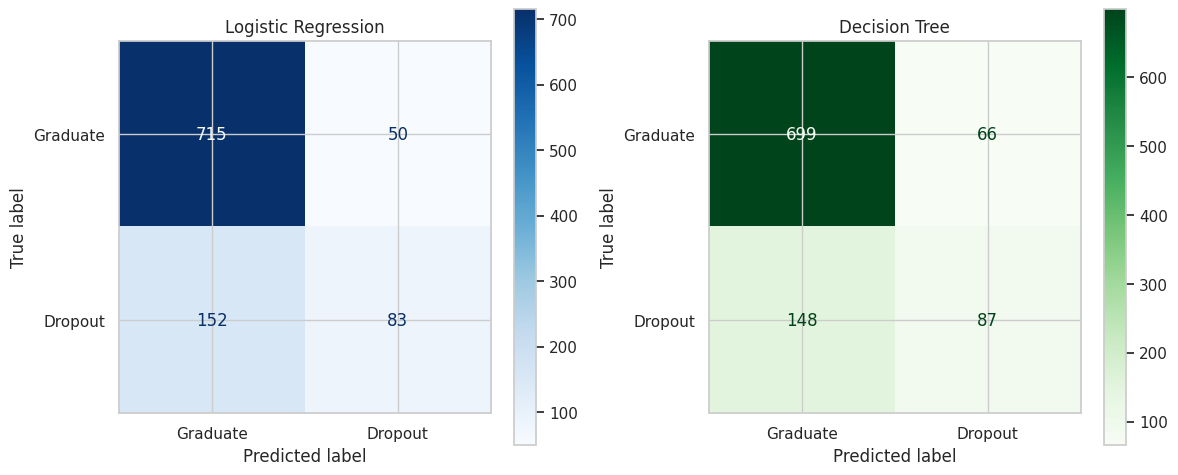

In [226]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(12,5))

cm_lr = confusion_matrix(y_test,pred_lr)
cm_dt = confusion_matrix(y_test,pred_dt)

ConfusionMatrixDisplay(
    cm_lr,
    display_labels=["Graduate","Dropout"]
).plot(ax=ax[0],cmap="Blues")

ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    cm_dt,
    display_labels=["Graduate","Dropout"]
).plot(ax=ax[1],cmap="Greens")

ax[1].set_title("Decision Tree")

plt.tight_layout()
plt.savefig("confusion_matrix.png",dpi=300)
plt.show()

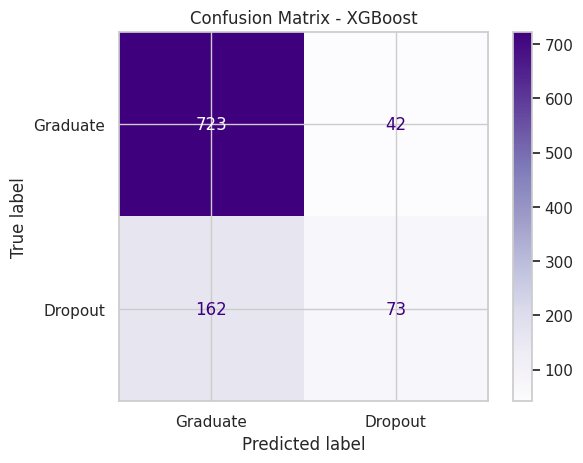

In [227]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test,pred_xgb)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Graduate","Dropout"]
).plot(cmap="Purples")

plt.title("Confusion Matrix - XGBoost")

plt.show()

###ROC Curve

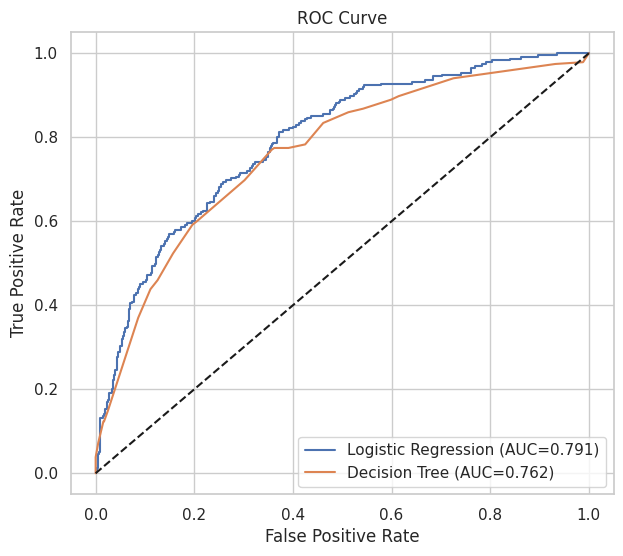

In [228]:
from sklearn.metrics import roc_curve, roc_auc_score

prob_lr = best_lr.predict_proba(X_test_scaled)[:,1]
prob_dt = best_dt.predict_proba(X_test)[:,1]

fpr_lr,tpr_lr,_ = roc_curve(y_test,prob_lr)
fpr_dt,tpr_dt,_ = roc_curve(y_test,prob_dt)

auc_lr = roc_auc_score(y_test,prob_lr)
auc_dt = roc_auc_score(y_test,prob_dt)

plt.figure(figsize=(7,6))

plt.plot(fpr_lr,tpr_lr,label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_dt,tpr_dt,label=f"Decision Tree (AUC={auc_dt:.3f})")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("roc_curve.png",dpi=300)

plt.show()

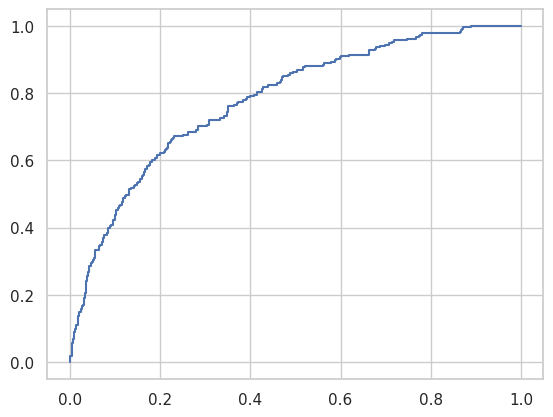

In [229]:
prob_xgb = best_xgb.predict_proba(X_test)[:,1]

fpr_xgb,tpr_xgb,_ = roc_curve(y_test,prob_xgb)

auc_xgb = roc_auc_score(y_test,prob_xgb)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC={auc_xgb:.3f})"
)

##Feature Importance

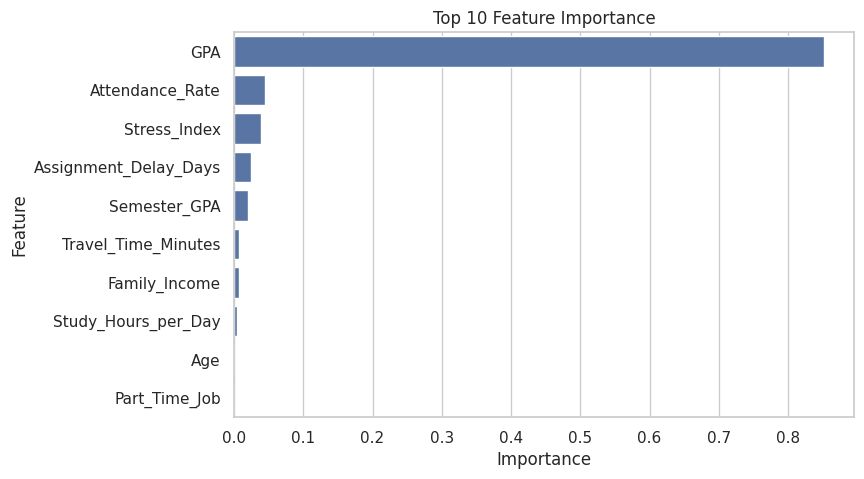

In [230]:
import pandas as pd
import seaborn as sns
import numpy as np

importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")
plt.savefig("feature_importance.png",dpi=300)

plt.show()

## SHAP Model Interpretation

In [231]:
!pip install shap -q

In [232]:
import shap

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

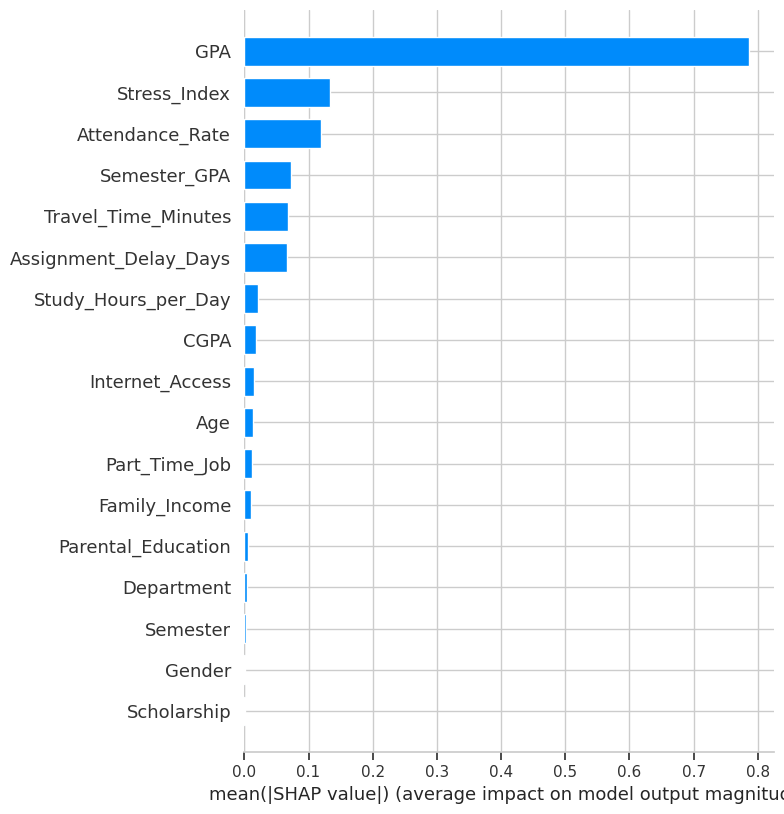

In [233]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

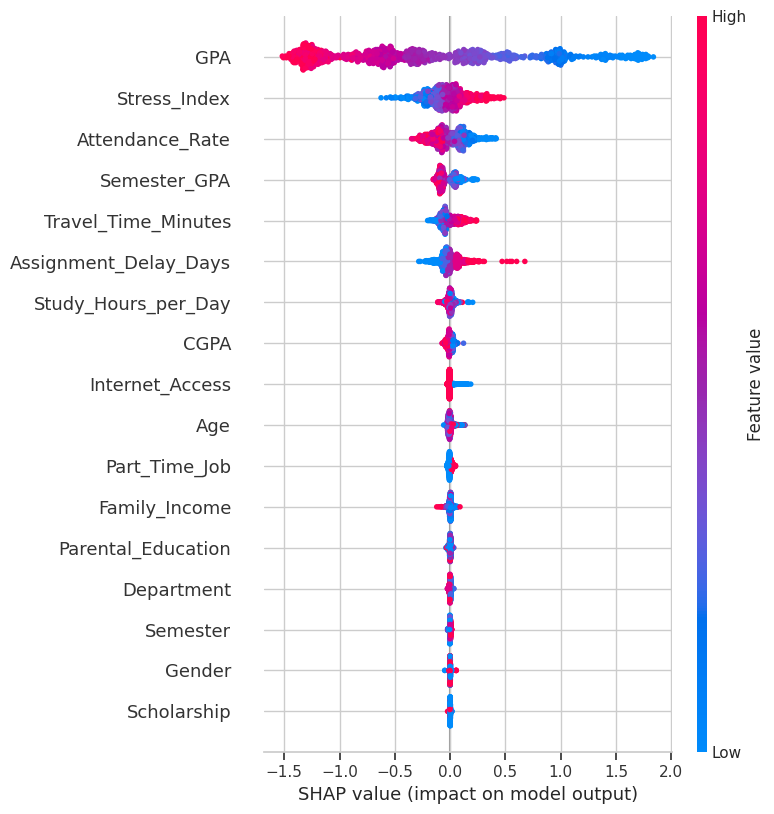

<Figure size 640x480 with 0 Axes>

In [240]:
shap.summary_plot(
    shap_values,
    X_test
)
plt.savefig("shap_summary.png",dpi=300)

##Best Model Selection

Berdasarkan hasil evaluasi terhadap tiga model yang diuji, yaitu Logistic Regression, Decision Tree, dan XGBoost, model terbaik dipilih berdasarkan nilai Accuracy, Precision, Recall, F1-Score, ROC-AUC, serta hasil interpretasi model.

Hasil evaluasi menunjukkan bahwa **Logistic Regression** memberikan performa terbaik dibandingkan model lainnya dengan kemampuan klasifikasi yang lebih baik pada data pengujian. Selain memiliki nilai evaluasi yang tinggi, interpretasi menggunakan SHAP menunjukkan bahwa fitur-fitur seperti GPA, CGPA, Attendance Rate, dan Study Hours per Day merupakan faktor yang paling berpengaruh terhadap prediksi status dropout mahasiswa.

Oleh karena itu, model Logistic Regression dipilih sebagai model akhir yang digunakan pada proses deployment karena memberikan keseimbangan terbaik antara performa prediksi dan interpretabilitas model.

# Deployment Plan

Model terbaik akan disimpan dalam format `.pkl` dan dapat digunakan kembali pada aplikasi sederhana berbasis Python. Pengguna nantinya hanya perlu memasukkan data mahasiswa, kemudian sistem akan memberikan hasil prediksi berupa status mahasiswa berpotensi dropout atau tidak.

###Save Best Model

In [235]:
import joblib

# Simpan model terbaik
joblib.dump(best_lr, "logistic_regression_model.pkl")

# Simpan scaler karena Logistic Regression menggunakan feature scaling
joblib.dump(scaler, "scaler.pkl")

print("Best model dan scaler berhasil disimpan.")

Best model dan scaler berhasil disimpan.


### Load Best Model

In [236]:
import joblib

loaded_model = joblib.load("logistic_regression_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model berhasil dimuat kembali.")

Model berhasil dimuat kembali.


### Evaluate Loaded Model

In [237]:
from sklearn.metrics import accuracy_score

# Scaling data test
X_test_scaled = loaded_scaler.transform(X_test)

# Prediksi
pred_loaded = loaded_model.predict(X_test_scaled)

print("Accuracy setelah model di-load:")
print(f"{accuracy_score(y_test, pred_loaded):.4f}")

Accuracy setelah model di-load:
0.7980


### Prediction Demo

In [238]:
import pandas as pd

# Ambil satu contoh data dari test set
sample = X_test.iloc[[0]]

# Scaling
sample_scaled = loaded_scaler.transform(sample)

# Prediksi
prediction = loaded_model.predict(sample_scaled)[0]

print("=== HASIL PREDIKSI ===")

if prediction == 1:
    print("Prediksi: Dropout")
else:
    print("Prediksi: Graduate")

=== HASIL PREDIKSI ===
Prediksi: Graduate


### Deployment Summary
Model berhasil disimpan dalam format `.pkl` dan dapat digunakan kembali untuk melakukan prediksi tanpa proses pelatihan ulang. Hal ini menunjukkan bahwa model siap untuk diintegrasikan ke dalam aplikasi prediksi kelulusan mahasiswa di masa mendatang.